In [1]:
import os, sys
import pickle

import matplotlib_inline
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import astropy.units as un
from astropy.cosmology import Planck18
import astropy.constants as const
import seaborn as sns
import numpy as np
from scipy.integrate import simpson, quad, dblquad
from scipy.interpolate import interp1d, griddata
from scipy.optimize import fsolve
import pymaster as nmt
from tqdm import tqdm

from matplotlib import gridspec
from matplotlib import ticker
from matplotlib.lines import Line2D

import healpy as hp
import scipy.special as sp

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2
# Load plot settings

from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']


In [2]:
unwise_auto_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq_unwise/clean_auto_Cls_binning150.npy")
unwise_auto_cov = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq_unwise/covariance_clean_PP_binning150_K22.npy')

unwise_cross_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq_unwise/cross_Pg_Cls_binning150_K22.npy")
unwise_cross_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq_unwise/covariance_clean_gP_binning150_K22.npy")


original_auto_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/clean_auto_Cls_binning150.npy")
original_auto_cov = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/covariance_clean_PP_binning150_K22.npy')

original_cross_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/cross_Pg_Cls_binning150_K22.npy")
original_cross_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/covariance_clean_gP_binning150_K22.npy")

ells = nmt.NmtBin.from_nside_linear(2048, 150).get_effective_ells()

In [3]:
# Normalization factor used in McCarthy et al. for 353 GHz reference
TCMB_eV = 0.000235264 
x = 2 * np.pi * 0.000232349 / TCMB_eV  # 353 GHz in eV units
mc_prefac = TCMB_eV * x**2 / (1 - np.exp(-x))
new_prefac = 2 * np.pi * 410e6 * 6.58212e-16

In [4]:
signal_ls = np.load("/projectnb/darkcosmo/dark_photon_project/dark_photons_radio_sky/notebooks_for_paper/data/ls.npy")
cross_signal = np.load("/projectnb/darkcosmo/dark_photon_project/dark_photons_radio_sky/notebooks_for_paper/data/Cl_gP_mA5.623e-13_modelK22.npy")

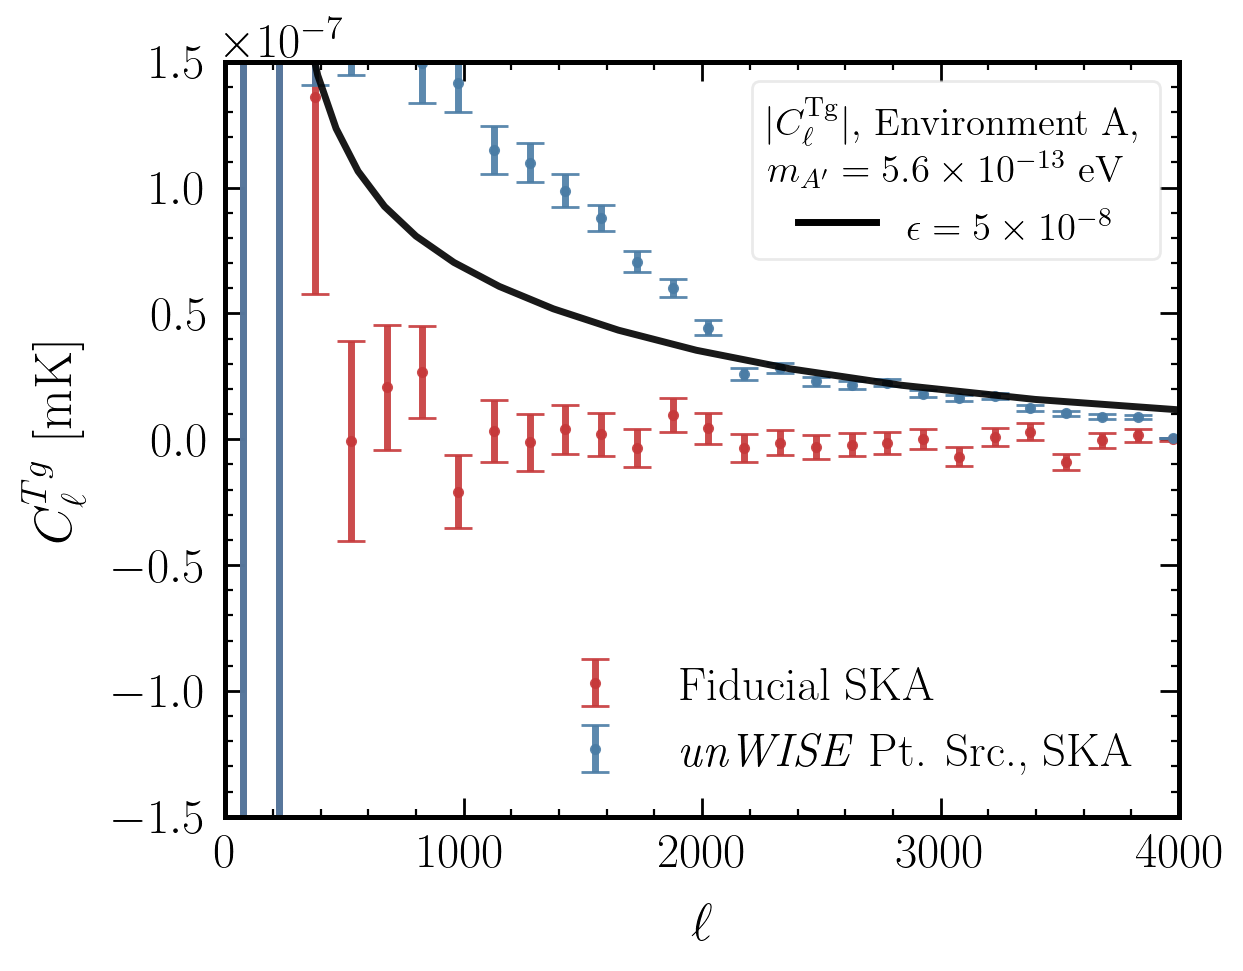

In [18]:
plt.errorbar(ells, new_prefac**-1 * original_cross_Cls, yerr=new_prefac**-1 * np.sqrt(np.diag(original_cross_cov)), fmt=".", label="Fiducial SKA")
plt.errorbar(ells, new_prefac**-1 * unwise_cross_Cls, yerr=new_prefac**-1 * np.sqrt(np.diag(unwise_cross_cov)), fmt=".", label=r"\textit{unWISE} Pt. Src., SKA")
plt.errorbar(signal_ls, (2.73e3)* (5e-8)**2  * new_prefac**-1 * cross_signal, fmt="k-")
# plt.xscale("log")
# plt.yscale("log")
big_eps_line = Line2D([0,1],[0,1],linestyle='-', color='k')
legend2 = plt.legend([big_eps_line], [r"$\epsilon=5\times10^{-8}$"], 
                     fontsize=14, loc="upper right", frameon=True, 
                     title=r"$|C_\ell^{\rm Tg}|$, Environment A,"+"\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14)
plt.legend()
plt.gca().add_artist(legend2)
plt.ylim(-1.5e-7, 1.5e-7)
plt.xlim(0, 4000)
# plt.axhline(0, color='k', linestyle='--')
plt.ylabel(r"$ C_\ell^{Tg} $ [mK]")
plt.xlabel(r"$\ell$ ")
plt.savefig("plots/radio_bias_SKA_comparison.pdf", bbox_inches='tight')


In [7]:
unwise_auto_Planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck_unwise/clean_auto_Cls_binning150.npy")
unwise_auto_Planck_cov = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck_unwise/covariance_clean_PP_binning150_K22.npy')

unwise_cross_Planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck_unwise/cross_Pg_Cls_binning150_K22.npy")
unwise_cross_Planck_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck_unwise/covariance_clean_gP_binning150_K22.npy")


original_auto_Planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/clean_auto_Cls_binning150.npy")
original_auto_Planck_cov = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/covariance_clean_PP_binning150_K22.npy')

original_cross_Planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/cross_Pg_Cls_binning150_K22.npy")
original_cross_Planck_cov = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/covariance_clean_gP_binning150_K22.npy")
ells = nmt.NmtBin.from_nside_linear(2048, 150).get_effective_ells()

In [ ]:
# digitized data from McCarthy et al, arXiv:2406.02546
mccarthy_ells = np.array([227.5424868535669,
                377.8671068963559,
                530.9851126361218,
                681.2060911601186,
                828.6682311600691, 
                978.6819266464809,
                1128.7301693058237,
                1278.911665346471,
                1429.6163042914989, 
                1579.6497410195855, 
                1728.9280752536126,
                1879.1836009505403,
                ])
mccarthy_lCl_Tg_uK = np.array([0.00007100085627635759, 
                  0.00004516450623453082, 
                  0.00002490209577956924, 
                  0.000013699928191233365, 
                  -0.000007954239801797979, 
                  0.00001011195751684786, 
                  0.000023300094017663416, 
                  0.00001767285307827644,
                  -0.0000618221659596835,
                  -0.00004654343196551215,
                  0.00007535577418980703,
                  0.00005927554578364085
                  ])
upper_Mccarthy_error = np.array([0.00008867200782766628, 
                                 0.00005011225066091601, 
                                 0.000031156656435443123, 
                                 0.000022935833095309477, 
                                 0.000003980569434931282, 
                                 0.000023065084047337785, 
                                 0.000040983695570731815, 
                                 0.0000425647884186895, 
                                 -0.00002750178905425811, 
                                 0.0000037181007497382173, 
                                 0.00014999414685047284, 
                                 0.00017958236734702215
                                ]) - mccarthy_lCl_Tg_uK
lower_Mccarthy_error = mccarthy_lCl_Tg_uK - np.array([0.0000534321159070040, 
                                 0.0000400769555159653, 
                                 0.00001785372532936736, 
                                 0.00000426584711165874, 
                                 -0.00001842480211884726, 
                                 -0.00000330673807776512, 
                                 0.000005742150824596017, 
                                 -0.000005979026303332699,
                                 -0.00009564745276189474, 
                                 -0.0000959337221339063, 
                                 0.0000013330735914662904, 
                                 -0.000060098151912591847
                                 ]) 

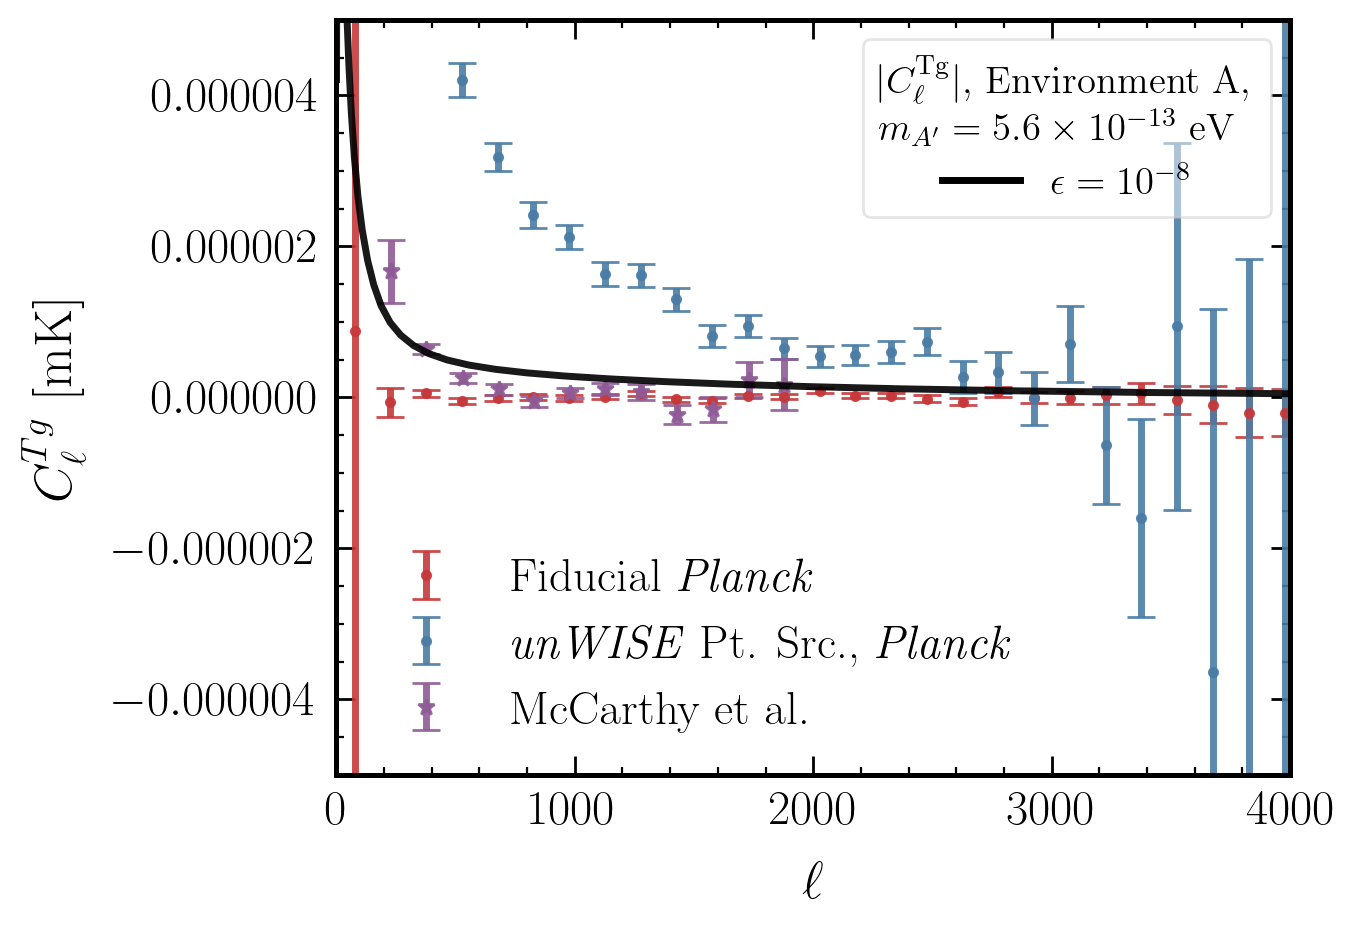

In [19]:
plt.errorbar(ells,  original_cross_Planck_Cls * mc_prefac / new_prefac, yerr=np.sqrt(np.diag(original_cross_Planck_cov)) * mc_prefac / new_prefac, fmt=".", label=r"Fiducial \textit{Planck}")

plt.errorbar(ells, unwise_cross_Planck_Cls * mc_prefac / new_prefac, yerr=np.sqrt(np.diag(unwise_cross_Planck_cov)) * mc_prefac / new_prefac, fmt=".", label=r"\textit{unWISE} Pt. Src., \textit{Planck}")
plt.errorbar(mccarthy_ells, (1e-3) * mccarthy_lCl_Tg_uK / mccarthy_ells * mc_prefac / new_prefac, yerr=np.array([upper_Mccarthy_error, lower_Mccarthy_error])/mccarthy_ells * mc_prefac / new_prefac * 1e-3, 
             fmt="*", color=cols_default[3], label="McCarthy et al.")
plt.errorbar(signal_ls, (2.73e3)* (10e-8)**2  * new_prefac**-1 * cross_signal, fmt="k-")

# plt.xscale("log")
# plt.yscale("log")
big_eps_line = Line2D([0,1],[0,1],linestyle='-', color='k')
legend2 = plt.legend([big_eps_line], [r"$\epsilon=10^{-8}$"], 
                     fontsize=14, loc="upper right", frameon=True, 
                     title=r"$|C_\ell^{\rm Tg}|$, Environment A,"+"\n"+ r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14, framealpha=0.5)
plt.legend(loc="lower left")
plt.gca().add_artist(legend2)
plt.ylim(-50e-7, 50e-7)
plt.xlim(0, 4000)
plt.ylabel(r"$C_\ell^{Tg} $ [mK]")
plt.xlabel(r"$\ell$ ")
plt.savefig("plots/radio_bias_Planck_comparison.pdf", bbox_inches='tight')